# 任意のAnsatzを用いた変分量子固有値ソルバー(VQE)

VQEで化学計算を行う際には、Hartree-Fock波動関数のような初期波動関数状態に対してユニタリ行列を作用させます。そして、そのユニタリ操作は使用するAnsatzによって決まります。今回は、水素分子の電子状態を、自分たちで作成したAnsatzを用いたVQEで計算します。Hardware Efficient Ansatz(HEA)を使用します。

必要なライブラリをインストールします。ハミルトニアンはOpenFermionを使って取得します。

In [1]:
!pip install git+https://github.com/blueqat/blueqatSDK openfermion openfermionpyscf pyscf

/Users/yuichirominato/.pyenv/shims/pip: line 8: /opt/homebrew/opt/pyenv/bin/pyenv: No such file or directory


必要なライブラリをインポートします。VQEの最適化にはSciPyのminimizeを使用します。

In [2]:
from blueqat import Circuit
from openfermion import MolecularData, get_fermion_operator, jordan_wigner, get_sparse_operator
from openfermionpyscf import run_pyscf
import numpy as np
from scipy.optimize import minimize

## Ansatzの定義
ここではHardware Efficient Ansatz (HEA)を選びます。HEAでは、まず初期化された各量子ビットにRyゲートとRzゲートが作用し、その後CZゲートによって隣接する量子ビット同士が結合されます。このRy、Rz、CZゲートからなるブロックが複数回繰り返されます。(ゲートの種類や結合の仕方は研究によって多少異なることに注意してください。)物理的には、このAnsatzは、RyゲートとRzゲートによるブロッホ球上の回転を用いた各量子ビットの状態変化と、CZゲートによる波動関数の探索空間の拡張を組み合わせたものと解釈できます。
引数は量子ビット数 n_qubits とゲートの深さ n_depth です。この関数の中で波動関数が初期化されます。

In [3]:
def HEA(params,n_qubits,n_depth):
    #Wave function initialization |1100>
    circ=Circuit().x[2, 3]

    #Circuit creation
    params_devided=np.array_split(params,n_depth)
    for params_one_depth in params_devided:
        for i,param in enumerate(params_one_depth):
            if i < n_qubits:
                circ.ry(param)[i]
            else:
                circ.rz(param)[i%n_qubits]
        for qbit in range(n_qubits):
            if qbit < n_qubits-1:
                circ.cz[qbit,qbit+1]
    
    #Running the circuit (statevector as a NumPy array)
    wf = circ.run().numpy()
    return wf

## 期待値とコスト関数
得られた波動関数から期待値を求めます。

In [4]:
def expect(wf,hamiltonian):
    return np.vdot(wf, hamiltonian.dot(wf)).real

def cost(params,hamiltonian,n_qubits,n_depth):
    wf=HEA(params,n_qubits,n_depth)
    return expect(wf,hamiltonian)

## 分子情報の取得
水素分子の結合長を指定し、OpenFermionを使って分子の情報を取得します。基底関数系はSTO-3Gです。

(キャッシュされた分子データが見つからない場合は、PySCFを使ってHartree-FockおよびFCIエネルギーをその場で計算します。)

In [5]:
def get_molecule(length):
    geometry = [('H',(0.,0.,0.)),('H',(0.,0.,length))]
    description = f'{length:.2f}'
    molecule = MolecularData(geometry, "sto-3g",1,description=description)
    try:
        molecule.load()
    except (FileNotFoundError, OSError, KeyError):
        # No cached data found: compute Hartree-Fock/FCI with PySCF instead.
        molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
        molecule.save()
    return molecule

## 計算の実行とプロット
各結合長についてVQEを実行します(数分かかります)。その後、VQEとFull CI(FCI)の計算結果をエネルギーと結合長について比較します。

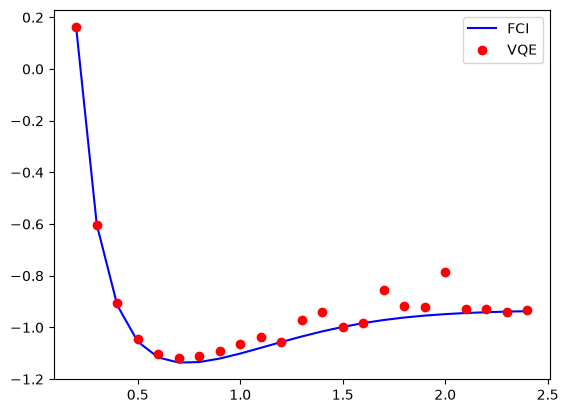

In [6]:
#Recording of bond length, HEA and FCI results
bond_len_list = [];energy_list=[];fullci_list=[]
#Execute the calculation for each bond length
for bond_len in np.arange(0.2,2.5,0.1):
    molecule = get_molecule(bond_len)
    #Determination of the number of bits, depth and initial parameter values
    n_qubits=molecule.n_qubits
    n_depth=4
    init_params=np.random.rand(2*n_qubits*n_depth)*0.1
    #Hamiltonian Definition
    hamiltonian = get_sparse_operator(jordan_wigner(get_fermion_operator(molecule.get_molecular_hamiltonian())))
    #Optimization run
    result=minimize(cost,x0=init_params,args=(hamiltonian,n_qubits,n_depth))
    #Recording of bond length, HEA and FCI results
    bond_len_list.append(bond_len)
    energy_list.append(result.fun)
    fullci_list.append(molecule.fci_energy)

#Plotting
import matplotlib.pyplot as plt
plt.plot(bond_len_list,fullci_list,label="FCI",color="blue")
plt.plot(bond_len_list,energy_list, marker="o",label="VQE",color="red",linestyle='None')
plt.legend()

初期パラメータに依存しますが、結合長が大きい領域ではVQEのエネルギーがFCIのエネルギーからずれる傾向があります。これは、結合長が大きくなるにつれて、用意した初期波動関数が真の解と異なってくるためです。初期パラメータやAnsatzなどを変更することで、精度が改善する可能性があります。